# 02 PCA Yield Curve

**Book:** *Fixed Income Relative Value Analysis (2nd ed.)*  
**Focus:** Chapter 3 principal component analysis for curve decomposition, residual screening, and PCA-neutral trade structures.


## Goals

1. Load the local Treasury curve.
2. Compute a PCA on level data or changes.
3. Interpret factors as level / slope / curvature placeholders.
4. Scaffold PCA-neutral residual and butterfly trade analysis.


In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

REPO_ROOT = Path("/Users/zelin/Desktop/PA Investment/Invest_strategy")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from alpha_research.quant_data.api import get_data

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

START = "2024-02-26"
END = "2026-02-27"
BOOK_PDF = Path(r"""/Users/zelin/Desktop/阅读学习/Fixed Income Relative Value Analysis + Website A Practitioner’s Guide to the Theory, Tools, and Trades 2nd.pdf""")

print("Expected environment: conda activate ibkr-analytics && export PYTHONPATH=.")
print("Book PDF exists:", BOOK_PDF.exists())
print("Repo root:", REPO_ROOT)


Expected environment: conda activate ibkr-analytics && export PYTHONPATH=.
Book PDF exists: True
Repo root: /Users/zelin/Desktop/PA Investment/Invest_strategy


In [2]:
FRED_DIR = REPO_ROOT / "data" / "market_data" / "fred"
PRICES_DIR = REPO_ROOT / "data" / "market_data" / "prices"

def _filter_date(frame: pd.DataFrame, start=START, end=END, date_col="date"):
    out = frame.copy()
    out[date_col] = pd.to_datetime(out[date_col])
    return out[(out[date_col] >= start) & (out[date_col] <= end)]

def load_fred_series(series_ids, start=START, end=END):
    frames = []
    for parquet_file in sorted(FRED_DIR.glob("*.parquet")):
        df = pd.read_parquet(parquet_file)
        if "series_id" not in df.columns:
            continue
        sub = df[df["series_id"].isin(series_ids)]
        if not sub.empty:
            frames.append(_filter_date(sub, start=start, end=end))

    if not frames:
        return pd.DataFrame()

    joined = pd.concat(frames, ignore_index=True).drop_duplicates(["date", "series_id"])
    wide = (
        joined.pivot(index="date", columns="series_id", values="value")
        .sort_index()
        .apply(pd.to_numeric, errors="coerce")
    )
    wide.index = pd.to_datetime(wide.index)
    return wide

def load_local_price_series(tickers, start=START, end=END, value_col="close"):
    frames = []
    for parquet_file in sorted(PRICES_DIR.glob("*.parquet")):
        df = pd.read_parquet(parquet_file)
        if "ticker" not in df.columns or value_col not in df.columns:
            continue
        sub = df[df["ticker"].isin(tickers)]
        if not sub.empty:
            frames.append(_filter_date(sub, start=start, end=end))

    if not frames:
        return pd.DataFrame()

    joined = pd.concat(frames, ignore_index=True).drop_duplicates(["date", "ticker"])
    wide = (
        joined.pivot(index="date", columns="ticker", values=value_col)
        .sort_index()
        .apply(pd.to_numeric, errors="coerce")
    )
    wide.index = pd.to_datetime(wide.index)
    return wide


In [3]:
TENOR_MAP = {
    "DGS2": 2.0,
    "DGS3": 3.0,
    "DGS5": 5.0,
    "DGS7": 7.0,
    "DGS10": 10.0,
    "DGS20": 20.0,
    "DGS30": 30.0,
}

curve = load_fred_series(list(TENOR_MAP)).dropna().sort_index()
curve_changes_bp = curve.diff().dropna() * 100.0

print('curve shape', curve.shape)
print('change shape', curve_changes_bp.shape)
curve.tail()


curve shape (498, 7)
change shape (497, 7)


series_id   DGS10  DGS2  DGS20  DGS3  DGS30  DGS5  DGS7
date                                                   
2026-02-18   4.09  3.47   4.65  3.50   4.71  3.66  3.86
2026-02-19   4.08  3.47   4.64  3.50   4.70  3.65  3.85
2026-02-20   4.08  3.48   4.66  3.50   4.72  3.65  3.85
2026-02-23   4.03  3.43   4.63  3.45   4.70  3.59  3.79
2026-02-25   4.05  3.45   4.63  3.49   4.70  3.61  3.82

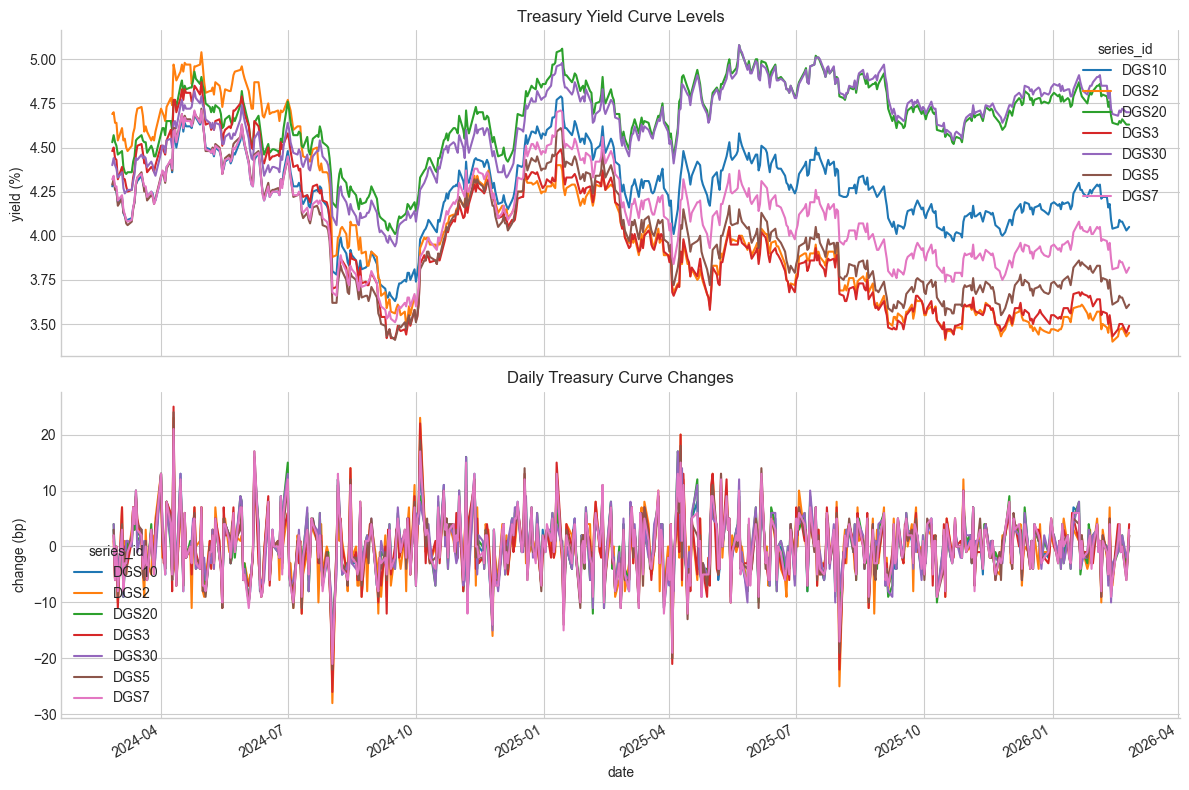

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
curve.plot(ax=axes[0], title='Treasury Yield Curve Levels')
axes[0].set_ylabel('yield (%)')

curve_changes_bp.plot(ax=axes[1], title='Daily Treasury Curve Changes')
axes[1].set_ylabel('change (bp)')
plt.tight_layout()
plt.show()


## Rolling PCA implementation

This section fits a PCA on a rolling window of daily Treasury yield changes. The implementation:

- works on daily changes in **basis points**
- stabilizes eigenvector signs across windows
- reconstructs the latest move from the first `n_components` factors
- stores tenor-level residuals for dislocation screening


In [5]:
def _sorted_eigendecomposition(cov: np.ndarray):
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = np.argsort(eigvals)[::-1]
    return eigvals[order], eigvecs[:, order]


def _stabilize_eigenvector_signs(current: np.ndarray, previous: np.ndarray | None):
    if previous is None:
        return current
    aligned = current.copy()
    for i in range(min(current.shape[1], previous.shape[1])):
        if np.dot(aligned[:, i], previous[:, i]) < 0:
            aligned[:, i] *= -1.0
    return aligned


def rolling_pca(frame: pd.DataFrame, window: int = 126, n_components: int = 3):
    x = frame.dropna().astype(float)
    if len(x) < window:
        raise ValueError(f'Need at least {window} observations, got {len(x)}')

    prev_vecs = None
    eigenvalues_rows = []
    explained_rows = []
    factor_rows = []
    residual_rows = []
    reconstruction_rows = []

    columns = list(x.columns)
    pc_names = [f'PC{i+1}' for i in range(n_components)]

    for end in range(window, len(x) + 1):
        sample = x.iloc[end - window:end]
        mean = sample.mean()
        centered = sample - mean
        cov = np.cov(centered.to_numpy(), rowvar=False)
        eigvals, eigvecs = _sorted_eigendecomposition(cov)
        eigvecs = _stabilize_eigenvector_signs(eigvecs, prev_vecs)
        prev_vecs = eigvecs[:, :n_components].copy()

        latest = x.iloc[end - 1]
        centered_latest = latest - mean
        factor_scores = centered_latest.to_numpy() @ eigvecs[:, :n_components]
        reconstructed = mean.to_numpy() + eigvecs[:, :n_components] @ factor_scores
        residual = latest.to_numpy() - reconstructed
        explained = eigvals[:n_components] / eigvals.sum()

        as_of = x.index[end - 1]
        eigenvalues_rows.append(pd.Series(eigvals[:n_components], index=pc_names, name=as_of))
        explained_rows.append(pd.Series(explained, index=pc_names, name=as_of))
        factor_rows.append(pd.Series(factor_scores, index=pc_names, name=as_of))
        residual_rows.append(pd.Series(residual, index=columns, name=as_of))
        reconstruction_rows.append(pd.Series(reconstructed, index=columns, name=as_of))

    return {
        'input': x,
        'window': window,
        'n_components': n_components,
        'rolling_eigenvalues': pd.DataFrame(eigenvalues_rows),
        'rolling_explained_variance': pd.DataFrame(explained_rows),
        'rolling_factor_scores': pd.DataFrame(factor_rows),
        'rolling_residuals': pd.DataFrame(residual_rows),
        'rolling_reconstruction': pd.DataFrame(reconstruction_rows),
        'latest_eigenvectors': pd.DataFrame(prev_vecs, index=columns, columns=pc_names),
    }


rpca = rolling_pca(curve_changes_bp, window=126, n_components=3)
rpca['rolling_explained_variance'].tail()


                 PC1       PC2       PC3
2026-02-18  0.871520  0.092279  0.019314
2026-02-19  0.871277  0.092317  0.019414
2026-02-20  0.871117  0.092501  0.019393
2026-02-23  0.871603  0.092124  0.019369
2026-02-25  0.871312  0.092313  0.019572

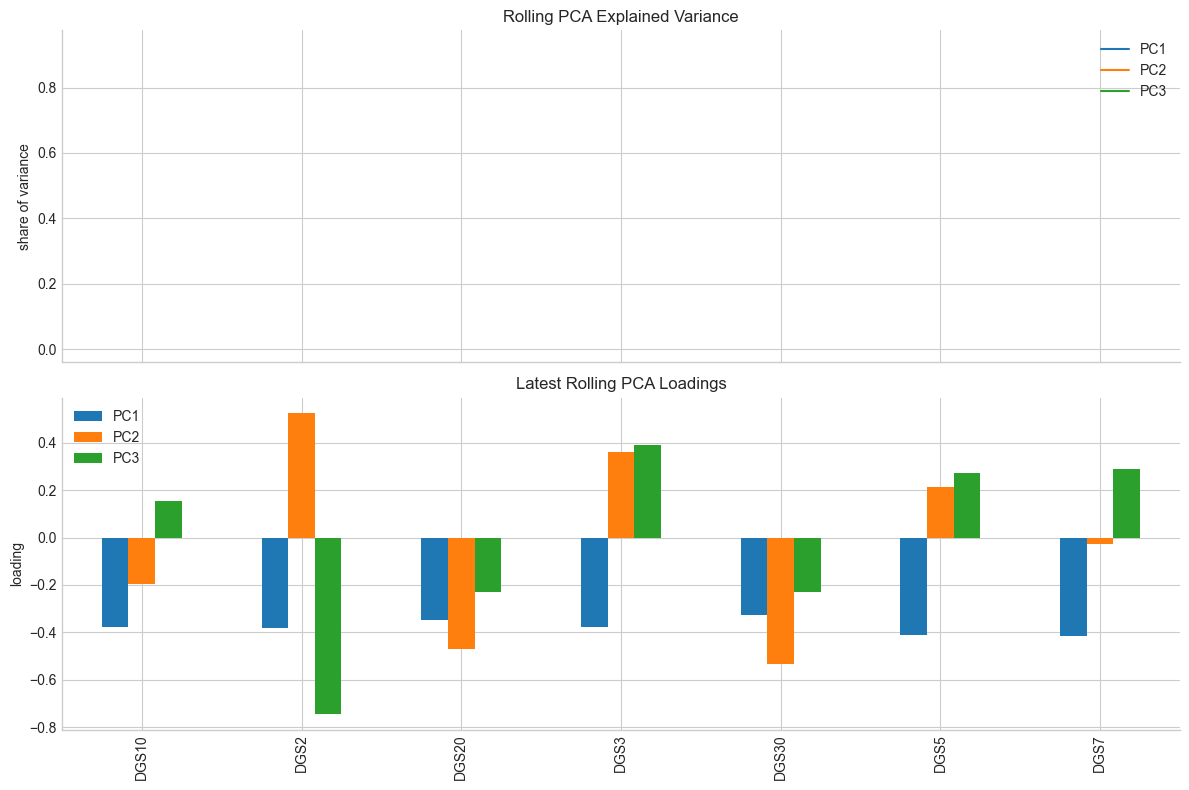

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
rpca['rolling_explained_variance'].plot(ax=axes[0], title='Rolling PCA Explained Variance')
axes[0].set_ylabel('share of variance')

rpca['latest_eigenvectors'].plot(kind='bar', ax=axes[1], title='Latest Rolling PCA Loadings')
axes[1].set_ylabel('loading')
plt.tight_layout()
plt.show()


## Residual construction

We use the first three rolling PCA factors to reconstruct the latest daily curve move and define tenor-level residuals:

- positive residual: tenor cheapened more than the factor model explains
- negative residual: tenor richened more than the factor model explains

This gives a direct screen for local dislocations after stripping out broad level/slope/curvature moves.


In [7]:
residuals = rpca['rolling_residuals'].copy()
residual_zscores = (residuals - residuals.rolling(60).mean()) / residuals.rolling(60).std()
latest_residual = residuals.iloc[-1].rename('latest_residual_bp')
latest_residual_z = residual_zscores.iloc[-1].rename('latest_residual_z')

residual_snapshot = pd.concat([latest_residual, latest_residual_z], axis=1).sort_values('latest_residual_z')
residual_snapshot


       latest_residual_bp  latest_residual_z
DGS5            -1.125147          -2.543451
DGS20           -0.205082          -0.453117
DGS30            0.040544           0.107914
DGS10            0.302596           0.510377
DGS7             0.425615           0.792659
DGS3             0.484752           0.879266
DGS2             0.120585           1.774173

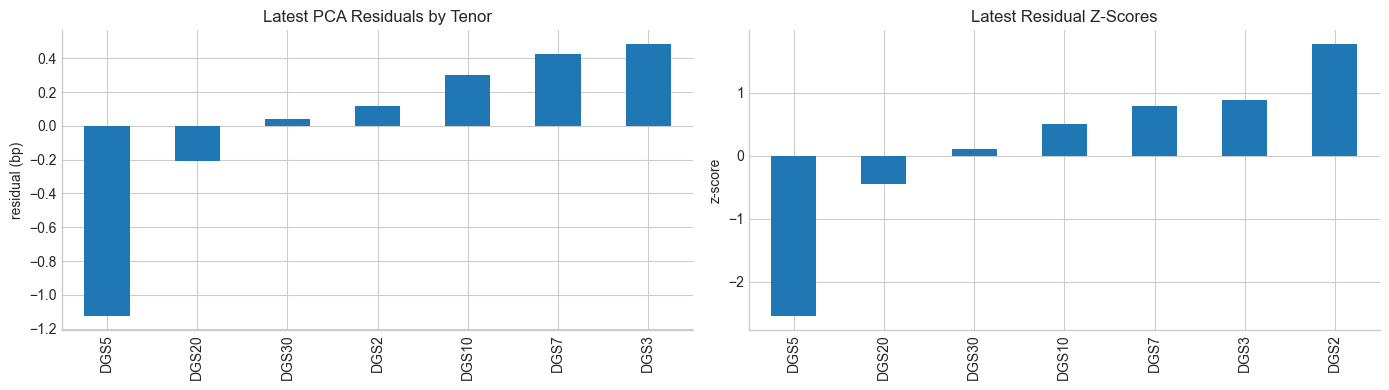

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
latest_residual.sort_values().plot(kind='bar', ax=axes[0], title='Latest PCA Residuals by Tenor')
axes[0].set_ylabel('residual (bp)')

latest_residual_z.sort_values().plot(kind='bar', ax=axes[1], title='Latest Residual Z-Scores')
axes[1].set_ylabel('z-score')
plt.tight_layout()
plt.show()


## Basic trade structure example: PCA-neutral 2Y / 5Y / 10Y butterfly

We build a simple three-leg structure with the 5Y as the anchor leg and solve for wing weights so the position is neutral to the first two PCA factors.

Interpretation:

- if the trade spread is high relative to its history, the belly may be rich versus wings
- if the trade spread is low, the belly may be cheap versus wings


In [9]:
def solve_pca_neutral_weights(eigenvectors: pd.DataFrame, belly: str = 'DGS5', wings=('DGS2', 'DGS10'), neutral_pcs=('PC1', 'PC2')):
    lhs = eigenvectors.loc[list(wings), list(neutral_pcs)].to_numpy().T
    rhs = -eigenvectors.loc[belly, list(neutral_pcs)].to_numpy()
    wing_weights = np.linalg.solve(lhs, rhs)
    weights = pd.Series(0.0, index=eigenvectors.index, name='weight')
    weights.loc[belly] = 1.0
    weights.loc[list(wings)] = wing_weights
    return weights


trade_weights = solve_pca_neutral_weights(rpca['latest_eigenvectors'])
trade_weights


DGS10   -0.491112
DGS2    -0.591378
DGS20    0.000000
DGS3     0.000000
DGS30    0.000000
DGS5     1.000000
DGS7     0.000000

In [10]:
selected_tenors = ['DGS2', 'DGS5', 'DGS10']
trade_curve = curve[selected_tenors].mul(trade_weights[selected_tenors], axis=1).sum(axis=1).rename('pca_neutral_fly')
trade_zscore = ((trade_curve - trade_curve.rolling(60).mean()) / trade_curve.rolling(60).std()).rename('zscore')
trade_signal = pd.Series(np.where(trade_zscore > 1.5, -1, np.where(trade_zscore < -1.5, 1, 0)), index=trade_zscore.index, name='signal')
trade_summary = pd.concat([trade_curve, trade_zscore, trade_signal], axis=1)
trade_summary.tail(10)


            pca_neutral_fly    zscore  signal
date                                         
2026-02-10        -0.383279  0.672866       0
2026-02-11        -0.384498  0.597671       0
2026-02-12        -0.390729  0.310594       0
2026-02-13        -0.384777  0.540522       0
2026-02-17        -0.387430  0.397398       0
2026-02-18        -0.400729 -0.237229       0
2026-02-19        -0.405818 -0.507293       0
2026-02-20        -0.411732 -0.865966       0
2026-02-23        -0.417607 -1.167510       0
2026-02-25        -0.419257 -1.341575       0

factor neutrality check
PC1    0.000000
PC2    0.000000
PC3    0.639739
dtype: float64


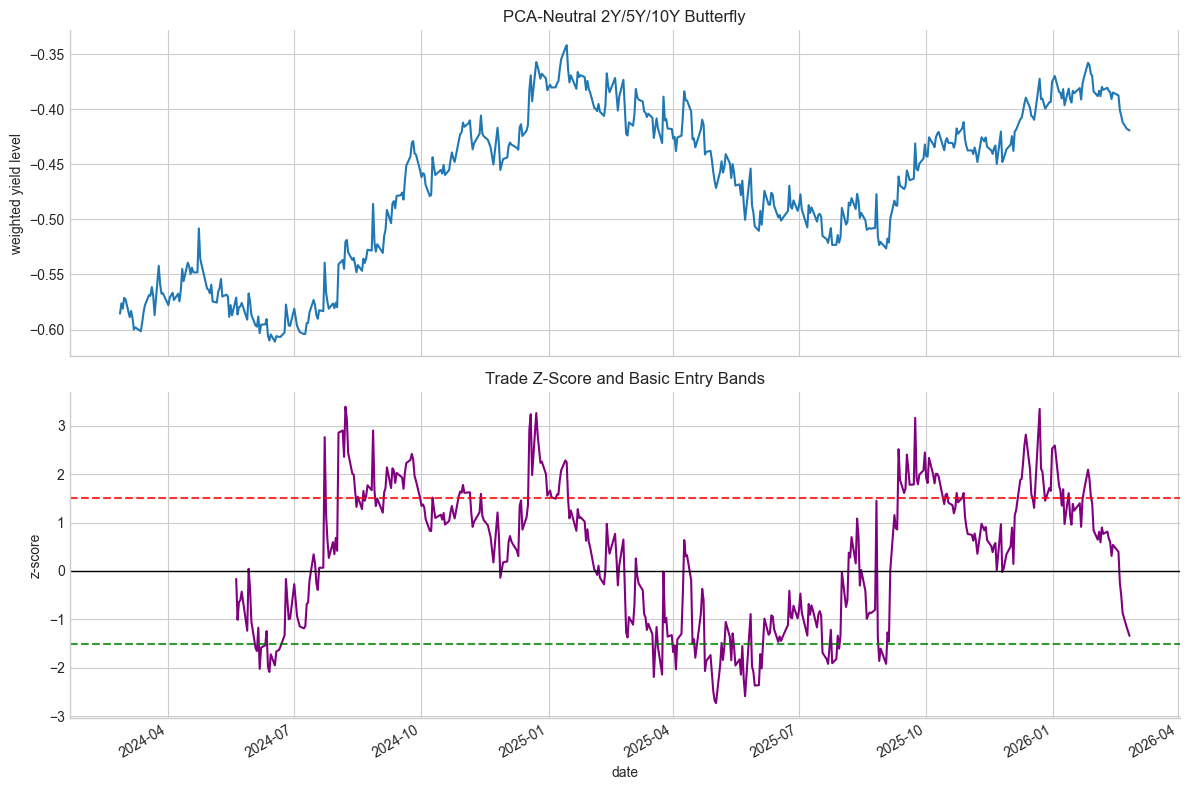

In [11]:
neutrality_check = rpca['latest_eigenvectors'].T @ trade_weights
print('factor neutrality check')
print(neutrality_check)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
trade_summary['pca_neutral_fly'].plot(ax=axes[0], title='PCA-Neutral 2Y/5Y/10Y Butterfly')
axes[0].set_ylabel('weighted yield level')

trade_summary['zscore'].plot(ax=axes[1], color='purple', title='Trade Z-Score and Basic Entry Bands')
axes[1].axhline(1.5, color='red', linestyle='--', alpha=0.8)
axes[1].axhline(-1.5, color='green', linestyle='--', alpha=0.8)
axes[1].axhline(0.0, color='black', linewidth=1.0)
axes[1].set_ylabel('z-score')
plt.tight_layout()
plt.show()


## Notes on interpretation and next steps

- The current trade is a **structure example**, not a full production backtest.
- The residual and trade logic currently use Treasury constant-maturity yields as a local proxy.
- Natural next extensions:
  1. compare the PCA-neutral fly with the Chapter 2 OU workflow
  2. run the same trade on rolling subperiods to test eigenvector stability
  3. move from Treasury proxies to fitted-curve or swap-curve inputs once available


## Regime-conditioned PCA-2 butterfly analysis

The **PCA-2** signal is the PCA-neutral `2Y/5Y/10Y` butterfly signal from this notebook.

We evaluate:

- regime-conditioned hit rate
- regime-conditioned half-life of the trade spread

using the shared daily macro regime panel.


In [12]:
STUDY_DIR = REPO_ROOT / 'workstation' / 'playground' / 'studies' / '2026-03-26_fixed_income_relative_value_analysis_2e'
REGIME_PARQUET = STUDY_DIR / 'macro_regime_daily.parquet'

def estimate_half_life(series: pd.Series):
    x = series.dropna().astype(float)
    if len(x) < 30:
        return np.nan
    x_t = x.iloc[:-1].to_numpy()
    x_tp1 = x.iloc[1:].to_numpy()
    X = np.column_stack([np.ones_like(x_t), x_t])
    beta, *_ = np.linalg.lstsq(X, x_tp1, rcond=None)
    _, b = beta
    b = np.clip(b, 1e-6, 0.999999)
    theta = -np.log(b)
    return float(np.log(2) / max(theta, 1e-8))

trade_half_life = estimate_half_life(trade_summary['pca_neutral_fly'])
eval_horizon = int(max(5, min(60, round(trade_half_life))))
trade_summary['forward_change'] = trade_summary['pca_neutral_fly'].shift(-eval_horizon) - trade_summary['pca_neutral_fly']
trade_summary['hit'] = np.where(trade_summary['signal'] == 0, np.nan, (trade_summary['signal'] * trade_summary['forward_change'] > 0).astype(float))

regime_daily = pd.read_parquet(REGIME_PARQUET)
regime_daily.index = pd.to_datetime(regime_daily.index)
pca_regime = trade_summary.join(regime_daily[['regime']], how='left')
pca_regime.tail(10)


            pca_neutral_fly    zscore  signal  forward_change  hit          regime
date                                                                              
2026-02-10        -0.383279  0.672866       0             NaN  NaN    stable carry
2026-02-11        -0.384498  0.597671       0             NaN  NaN    stable carry
2026-02-12        -0.390729  0.310594       0             NaN  NaN    stable carry
2026-02-13        -0.384777  0.540522       0             NaN  NaN  funding stress
2026-02-17        -0.387430  0.397398       0             NaN  NaN  funding stress
2026-02-18        -0.400729 -0.237229       0             NaN  NaN  funding stress
2026-02-19        -0.405818 -0.507293       0             NaN  NaN  funding stress
2026-02-20        -0.411732 -0.865966       0             NaN  NaN  funding stress
2026-02-23        -0.417607 -1.167510       0             NaN  NaN  funding stress
2026-02-25        -0.419257 -1.341575       0             NaN  NaN  funding stress

In [13]:
pca_hit_rate = (
    pca_regime[pca_regime['signal'] != 0]
    .groupby('regime')
    .agg(signal_count=('signal', 'size'), hit_rate=('hit', 'mean'), avg_forward_change=('forward_change', 'mean'))
    .sort_values('hit_rate', ascending=False)
)
pca_half_life = pca_regime.groupby('regime')['pca_neutral_fly'].apply(estimate_half_life).rename('half_life')
pca_regime_summary = pca_hit_rate.join(pca_half_life)
pca_regime_summary


                 signal_count  hit_rate  avg_forward_change  half_life
regime                                                                
inflation shock            19  0.736842            0.011686   7.729398
growth scare               32  0.375000            0.070981  13.032339
funding stress             43  0.232558            0.004112   2.410814
stable carry               74  0.162162            0.001854  15.010105

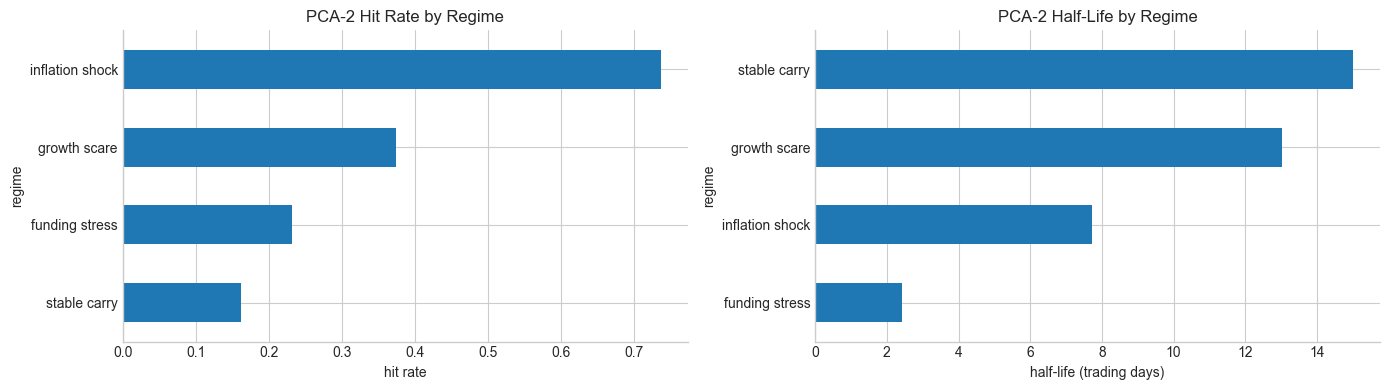

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
pca_regime_summary['hit_rate'].sort_values().plot(kind='barh', ax=axes[0], title='PCA-2 Hit Rate by Regime')
axes[0].set_xlabel('hit rate')

pca_regime_summary['half_life'].sort_values().plot(kind='barh', ax=axes[1], title='PCA-2 Half-Life by Regime')
axes[1].set_xlabel('half-life (trading days)')
plt.tight_layout()
plt.show()
